In [14]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.utils import to_categorical

In [15]:
X = np.load("../X_data.npy")
y = np.load("../y_gesture.npy")

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (720, 100, 64)
y shape: (720,)


In [16]:
gesture_names = {
    0: "bend",
    1: "forward_kick",
    2: "hand_clap",
    3: "horizontal_arm_wave",
    4: "sit_down",
    5: "squat",
    6: "still",
    7: "two_hands_wave",
    8: "walk"
}

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (576, 100, 64)
Test: (144, 100, 64)


In [18]:
num_classes = len(np.unique(y))

y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

print(y_train_cat.shape)

(576, 9)


In [19]:
model = Sequential([
    
    Conv1D(
        32,
        kernel_size=3,
        activation='relu',
        input_shape=(100,64)
    ),
    
    MaxPooling1D(pool_size=2),

    Conv1D(
        64,
        kernel_size=3,
        activation='relu'
    ),

    MaxPooling1D(pool_size=2),

    LSTM(64),

    Dropout(0.3),

    Dense(64, activation='relu'),

    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/opt/anaconda3/envs/csi_env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 98, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 49, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 47, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 23, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,153 (195.91 KB)

 Trainable params: 50,153 (195.91 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
history = model.fit(
    X_train,
    y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=30,
    batch_size=16
)

Epoch 1/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.1128 - loss: 2.3138 - val_accuracy: 0.1042 - val_loss: 2.2252
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.1007 - loss: 2.2528 - val_accuracy: 0.1181 - val_loss: 2.2008
Epoch 3/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.1302 - loss: 2.2186 - val_accuracy: 0.1042 - val_loss: 2.2131
Epoch 4/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.0903 - loss: 2.2559 - val_accuracy: 0.1181 - val_loss: 2.2090
Epoch 5/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.0972 - loss: 2.2288 - val_accuracy: 0.1528 - val_loss: 2.1963
Epoch 6/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.1250 - loss: 2.2257 - val_accuracy: 0.1667 - val_loss: 2.2181
Epoch 7/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.1406 - loss: 2.1899 - val_accuracy: 0.1181 - val_loss: 2.2133
Epoch 8/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.1267 - loss: 2.2190 - val_accuracy: 0.1111 - v

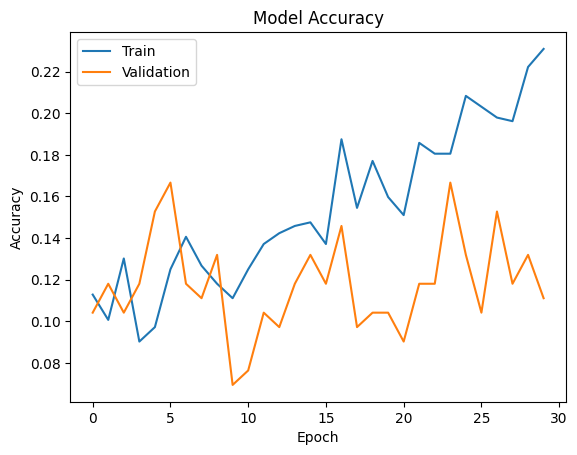

In [21]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")

plt.legend(['Train', 'Validation'])

plt.show()

In [22]:
loss, acc = model.evaluate(X_test, y_test_cat)

print("Test Accuracy:", acc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1111 - loss: 2.3391
Test Accuracy: 0.1111111119389534


In [23]:
predictions = model.predict(X_test)

pred_classes = np.argmax(predictions, axis=1)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


In [24]:
cm = confusion_matrix(y_test, pred_classes)

print(cm)

[[2 0 3 3 0 4 1 2 1]
 [5 0 0 1 5 4 0 0 1]
 [2 0 1 2 3 2 0 3 3]
 [3 0 1 2 4 3 0 2 1]
 [3 1 1 2 4 2 0 2 1]
 [3 1 0 0 3 4 0 5 0]
 [1 2 0 2 6 3 0 1 1]
 [1 0 1 5 6 1 0 1 1]
 [1 1 1 2 3 0 0 6 2]]


In [25]:
print(classification_report(
    y_test,
    pred_classes,
    target_names=list(gesture_names.values())
))

                     precision    recall  f1-score   support

               bend       0.10      0.12      0.11        16
       forward_kick       0.00      0.00      0.00        16
          hand_clap       0.12      0.06      0.08        16
horizontal_arm_wave       0.11      0.12      0.11        16
           sit_down       0.12      0.25      0.16        16
              squat       0.17      0.25      0.21        16
              still       0.00      0.00      0.00        16
     two_hands_wave       0.05      0.06      0.05        16
               walk       0.18      0.12      0.15        16

           accuracy                           0.11       144
          macro avg       0.09      0.11      0.10       144
       weighted avg       0.09      0.11      0.10       144

